# Siamang: Full Research Pipeline Demo

**Research Topic**: IT Workplace, Autonomy & Digital Monitoring Study 2026

This notebook demonstrates the complete lifecycle of a survey-based sociological study using the **Siamang** library:
1. **Design** — Define variables with strict sociological scales and build a multi-page questionnaire.
2. **Simulate & Deploy** — Generate synthetic respondent data and deploy to a local server.
3. **Analyze** — Validate data, compute frequencies, run statistical tests, and visualize results.

---

## Step 1: Survey Design & Variable Specification

In [1]:
import siamang as sg
from siamang import (
    AND, OR, Block, LikertScale, Matrix, MissingValue, MultiChoice,
    NumericInput, OpenText, Page, Questionnaire, SingleChoice, Variable, VariableMap,
)
print(f"Siamang version: {sg.__version__}")

Siamang version: 0.5.0


### 1.1 Variable Definitions (Codebook)

In [2]:
# Informed consent
consent = Variable("consent", scale="nominal", label="Informed Consent",
                   labels={1: "I agree to participate", 0: "I do not agree"})

# Demographics
age = Variable("age", scale="ratio", label="Age", dtype="int", valid_range=(18, 75),
               description="Respondent age in years.")

gender = Variable("gender", scale="nominal", label="Gender Identity",
                  labels={1: "Male", 2: "Female", 3: "Non-binary", 4: "Prefer to self-describe"},
                  missing=(MissingValue(code=9, label="Prefer not to say", kind="refusal"),))

# Professional Profile
it_role = Variable("it_role", scale="nominal", label="IT Role",
                   labels={1: "Software Engineer / Developer", 2: "Data Scientist / Analyst",
                           3: "DevOps / Infrastructure", 4: "Product / Project Manager", 5: "Other"})

experience = Variable("experience", scale="ratio", label="Years of Experience",
                      dtype="int", valid_range=(0, 50))

# Remote Work Frequency
remote_freq = Variable("remote_freq", scale="ordinal", label="Remote Work Frequency",
                       labels={1: "Never (Fully on-site)", 2: "Occasionally (1-2 days/week)",
                               3: "Hybrid (3 days/week)", 4: "Mostly remote (4 days/week)",
                               5: "Fully remote"})

# Surveillance Acceptance (Likert items)
surv_keystroke = Variable("surv_keystroke", scale="ordinal",
                          label="Keystroke logging / activity tracking",
                          labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral",
                                  4: "Agree", 5: "Strongly agree"})
surv_camera = Variable("surv_camera", scale="ordinal",
                       label="Webcam monitoring / periodic screenshots",
                       labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral",
                               4: "Agree", 5: "Strongly agree"})
surv_git = Variable("surv_git", scale="ordinal",
                    label="Git commit frequency metrics",
                    labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral",
                            4: "Agree", 5: "Strongly agree"})

# Outcome variables
satisfaction = Variable("satisfaction", scale="ordinal", label="Overall Job Satisfaction",
                        labels={1: "Very dissatisfied", 2: "Dissatisfied", 3: "Neutral",
                                4: "Satisfied", 5: "Very satisfied"})
autonomy = Variable("autonomy", scale="ordinal", label="Workplace Autonomy",
                    labels={1: "Very low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very high"})

# Open-ended
story = Variable("story", scale="nominal", label="Experience with algorithmic management")

# Aggregate into VariableMap
variables = VariableMap()
variables.add_many([consent, age, gender, it_role, experience, remote_freq,
                    surv_keystroke, surv_camera, surv_git, satisfaction, autonomy, story])
print(f"✓ Defined {len(variables)} research variables")

✓ Defined 12 research variables


### 1.2 Questionnaire Structure

In [3]:
# Page 1: Consent
q_consent = SingleChoice(
    text="Do you agree to participate in this academic study?",
    var=consent, required=True, display="buttons")
page_welcome = Page(name="welcome", title="Consent Gate", items=[q_consent])

# Page 2: Demographics (shown only if consent=1)
q_age = NumericInput("How old are you?", var=age, required=True, unit="years")
q_gender = SingleChoice("How do you identify your gender?", var=gender,
                        required=True, display="radio", other_specify=True)
page_demographics = Page(name="demographics", title="Demographic Profile",
                         items=[Block(title="Personal Information", items=[q_age, q_gender])],
                         show_if=consent.eq(1))

# Page 3: Professional Profile
q_role = SingleChoice("What is your primary professional role?", var=it_role,
                      required=True, display="dropdown")
q_exp = NumericInput("Years of professional experience?", var=experience,
                     required=True, unit="years")
q_remote = SingleChoice("Current remote work arrangement?", var=remote_freq,
                        required=True, display="radio")
page_professional = Page(name="professional", title="Professional Profile",
                         items=[q_role, q_exp, q_remote], show_if=consent.eq(1))

# Page 4: Surveillance Matrix (only for hybrid/remote workers)
q_surv = Matrix(
    text="To what extent do you agree that these monitoring methods are acceptable?",
    var=[surv_keystroke, surv_camera, surv_git])
page_surveillance = Page(name="surveillance", title="Workplace Monitoring",
                         items=[q_surv],
                         show_if=AND(consent.eq(1), remote_freq.ge(2)))

# Page 5: Satisfaction & Autonomy
q_sat = LikertScale("Overall job satisfaction?", var=satisfaction, points=5)
q_aut = LikertScale("How much autonomy over daily tasks?", var=autonomy, points=5)
page_outcomes = Page(name="outcomes", title="Job Outcomes",
                     items=[q_sat, q_aut], show_if=consent.eq(1))

# Page 6: Open-ended
q_story = OpenText(
    text="Share any experiences with digital tracking or algorithmic management.",
    var=story, multiline=True, max_chars=1000, placeholder="Write here...")
page_story = Page(name="story_page", title="Your Story",
                  items=[q_story], show_if=consent.eq(1))

# Assemble the questionnaire
survey = Questionnaire(
    title="IT Workplace, Autonomy & Monitoring Study 2026",
    pages=[page_welcome, page_demographics, page_professional,
           page_surveillance, page_outcomes, page_story],
    variables=variables)

survey.validate(strict=True)
print(survey.preview())

Questionnaire<IT Workplace, Autonomy & Monitoring Study 2026> with 10 questions


---
## Step 2: Simulation & Deployment

### 2.1 Simulate 250 Respondents

In [4]:
# Simulate synthetic data (respects all show_if routing logic)
survey_data = survey.simulate(n=250, seed=42)

print(f"DataFrame shape: {survey_data.frame.shape}")
print(f"Columns: {list(survey_data.frame.columns)}")
survey_data.frame.head(10)

DataFrame shape: (250, 12)
Columns: ['consent', 'age', 'gender', 'it_role', 'experience', 'remote_freq', 'surv_keystroke', 'surv_camera', 'surv_git', 'satisfaction', 'autonomy', 'story']


,consent,age,gender,it_role,experience,remote_freq,surv_keystroke,surv_camera,surv_git,satisfaction,autonomy,story
0,1,19.0,3.0,2.0,14.0,2.0,1.0,5.0,1.0,5.0,4.0,sample text
1,1,19.0,1.0,2.0,14.0,5.0,5.0,1.0,5.0,2.0,5.0,sample text
2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,46.0,3.0,1.0,48.0,2.0,4.0,3.0,3.0,2.0,2.0,sample text
4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,23.0,4.0,1.0,22.0,3.0,5.0,3.0,1.0,4.0,5.0,sample text
6,1,42.0,1.0,5.0,18.0,5.0,3.0,5.0,2.0,1.0,1.0,sample text
7,1,67.0,3.0,1.0,14.0,1.0,NaN,NaN,NaN,4.0,3.0,sample text
8,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Variable Summary

In [5]:
survey_data.describe_variables()

,name,label,scale,n,n_missing,n_unique
0,consent,Informed Consent,nominal,250,0,2
1,age,Age,ratio,250,122,51
2,gender,Gender Identity,nominal,250,122,4
3,it_role,IT Role,nominal,250,122,5
4,experience,Years of Experience,ratio,250,122,44
5,remote_freq,Remote Work Frequency,ordinal,250,122,5
6,surv_keystroke,Keystroke logging / activity tracking,ordinal,250,142,5
7,surv_camera,Webcam monitoring / periodic screenshots,ordinal,250,142,5
8,surv_git,Git commit frequency metrics,ordinal,250,142,5
9,satisfaction,Overall Job Satisfaction,ordinal,250,122,5


### 2.3 Data Validation Against Codebook

In [6]:
issues = survey_data.validate()
if not issues:
    print("✓ All data matches the codebook perfectly!")
else:
    print(f"Found {len(issues)} validation issue(s):")
    for issue in issues:
        print(f"  [{issue.severity.upper()}] {issue.message}")

✓ All data matches the codebook perfectly!


### 2.4 Local Deployment (Instructions)

To deploy this survey to a **local development server**:
```python
result = survey.deploy(backend='local', frontend='local')
# Opens browser at http://localhost:8000
# Responses stored in local SQLite database
```

To deploy to **production** (Supabase + Vercel):
```python
result = survey.deploy(backend='supabase', frontend='vercel')
print(result.url)  # → https://your-survey.vercel.app
```

To **collect responses** after deployment:
```python
df = result.collect()  # Returns a pandas DataFrame
```

---
## Step 3: Statistical Analysis

### 3.1 Univariate Frequencies

In [7]:
# IT Role distribution
print("IT Professional Roles Distribution:")
survey_data.analysis.frequencies("it_role", normalize=True, labels=True)

IT Professional Roles Distribution:


,value,label,n,percent
0,NaN,NaN,0.488,0.488
1,2.0,Data Scientist / Analyst,0.132,0.132
2,5.0,Other,0.108,0.108
3,3.0,DevOps / Infrastructure,0.100,0.100
4,1.0,Software Engineer / Developer,0.092,0.092
5,4.0,Product / Project Manager,0.080,0.080


In [8]:
# Remote Work Frequency distribution
print("Remote Work Frequency Distribution:")
survey_data.analysis.frequencies("remote_freq", normalize=True, labels=True)

Remote Work Frequency Distribution:


,value,label,n,percent
0,NaN,NaN,0.488,0.488
1,3.0,Hybrid (3 days/week),0.124,0.124
2,5.0,Fully remote,0.116,0.116
3,2.0,Occasionally (1-2 days/week),0.096,0.096
4,4.0,Mostly remote (4 days/week),0.096,0.096
5,1.0,Never (Fully on-site),0.080,0.080


### 3.2 Bivariate Analysis: Crosstab + Chi-Square

In [9]:
# Cross-tabulate IT Role × Remote Work Frequency
# H1: Software developers have higher remote work frequency
ct, stats = survey_data.analysis.crosstab(
    row="it_role", col="remote_freq",
    normalize="index",  # Row percentages
    chi2=True, cramers_v=True, labels=True)

print("Crosstab: Remote Work Frequency by IT Role (Row %)")
print("=" * 60)
display(ct.round(3) * 100)

print(f"\nChi-Square = {stats['chi2']:.3f}, p = {stats['p_value']:.4f}")
print(f"Cramer's V = {stats['cramers_v']:.3f}")
if stats['p_value'] < 0.05:
    print("→ Statistically significant association (p < 0.05)")
else:
    print("→ No statistically significant association (p ≥ 0.05)")

Crosstab: Remote Work Frequency by IT Role (Row %)


,Never (Fully on-site),Occasionally (1-2 days/week),Hybrid (3 days/week),Mostly remote (4 days/week),Fully remote,NaN
Software Engineer / Developer,13.0,21.7,26.1,13.0,26.1,0.0
Data Scientist / Analyst,18.2,15.2,21.2,21.2,24.2,0.0
DevOps / Infrastructure,16.0,16.0,32.0,16.0,20.0,0.0
Product / Project Manager,20.0,20.0,25.0,5.0,30.0,0.0
Other,11.1,22.2,18.5,33.3,14.8,0.0
NaN,0.0,0.0,0.0,0.0,0.0,100.0



Chi-Square = 269.027, p = 0.0000
Cramer's V = 0.464
→ Statistically significant association (p < 0.05)


### 3.3 Grouped Means & Kruskal-Wallis Test

In [10]:
# Mean Autonomy by Remote Work Frequency
# H2: Higher remote frequency → higher perceived autonomy
print("Mean Autonomy Score by Remote Work Frequency (Scale 1-5):")
autonomy_by_remote = survey_data.analysis.grouped_mean(
    column="autonomy", by="remote_freq", labels=True)
display(autonomy_by_remote)

# Non-parametric test
kw = survey_data.analysis.kruskal("autonomy", "remote_freq")
print(f"\nKruskal-Wallis H = {kw['statistic']:.3f}, p = {kw['p_value']:.4f}")
if kw['p_value'] < 0.05:
    print("→ Significant differences in autonomy across remote work groups")
else:
    print("→ No significant differences (fail to reject H0)")

Mean Autonomy Score by Remote Work Frequency (Scale 1-5):


,group,mean,n,label
0,1.0,3.100000,20.0,Never (Fully on-site)
1,2.0,3.208333,24.0,Occasionally (1-2 days/week)
2,3.0,2.935484,31.0,Hybrid (3 days/week)
3,4.0,2.750000,24.0,Mostly remote (4 days/week)
4,5.0,3.103448,29.0,Fully remote



Kruskal-Wallis H = 1.453, p = 0.8350
→ No significant differences (fail to reject H0)


### 3.4 Correlation: Satisfaction × Autonomy

In [11]:
# Spearman correlation between satisfaction and autonomy
sp = survey_data.analysis.spearman("satisfaction", "autonomy")
print(f"Spearman's ρ = {sp['rho']:.3f}, p = {sp['p_value']:.5f}, n = {int(sp['n'])}")
if sp['p_value'] < 0.05:
    print("→ Significant monotonic relationship between satisfaction and autonomy")
else:
    print("→ No significant correlation")

Spearman's ρ = 0.071, p = 0.42560, n = 128
→ No significant correlation


### 3.5 Data Visualization

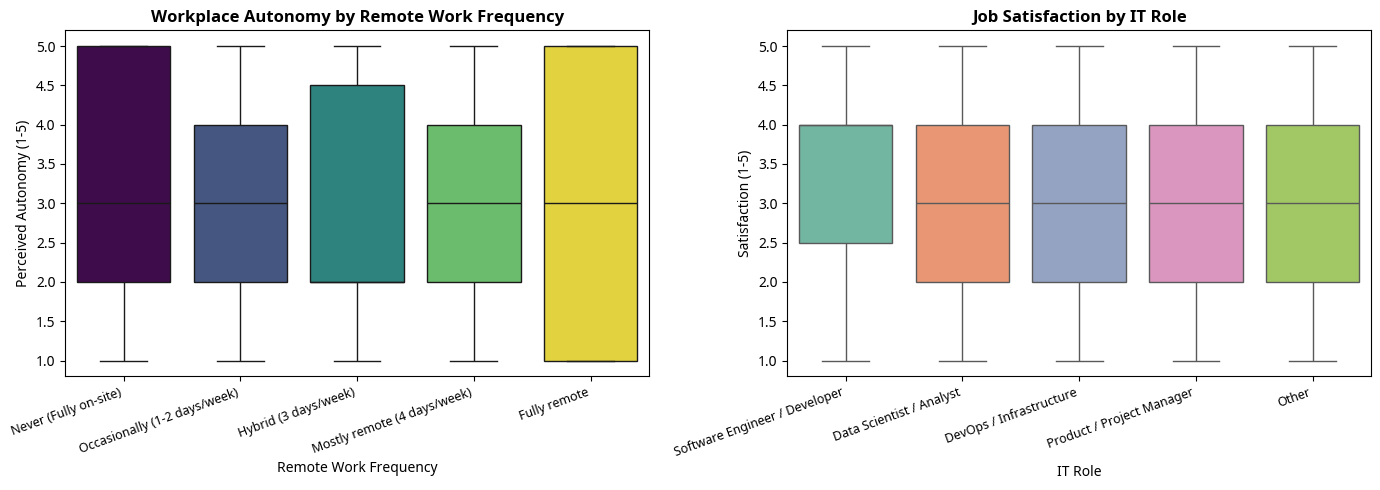

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Autonomy by Remote Work Frequency
sns.boxplot(data=survey_data.frame, x="remote_freq", y="autonomy",
            hue="remote_freq", palette="viridis", legend=False, ax=axes[0])
remote_labels = [variables["remote_freq"].labels[i]
                 for i in sorted(variables["remote_freq"].labels.keys())]
axes[0].set_xticks(range(len(remote_labels)))
axes[0].set_xticklabels(remote_labels, rotation=20, ha="right", fontsize=9)
axes[0].set_title("Workplace Autonomy by Remote Work Frequency", fontweight="bold")
axes[0].set_xlabel("Remote Work Frequency")
axes[0].set_ylabel("Perceived Autonomy (1-5)")

# Plot 2: Satisfaction by IT Role
sns.boxplot(data=survey_data.frame, x="it_role", y="satisfaction",
            hue="it_role", palette="Set2", legend=False, ax=axes[1])
role_labels = [variables["it_role"].labels[i]
               for i in sorted(variables["it_role"].labels.keys())]
axes[1].set_xticks(range(len(role_labels)))
axes[1].set_xticklabels(role_labels, rotation=20, ha="right", fontsize=9)
axes[1].set_title("Job Satisfaction by IT Role", fontweight="bold")
axes[1].set_xlabel("IT Role")
axes[1].set_ylabel("Satisfaction (1-5)")

plt.tight_layout()
plt.show()

### 3.6 Banner Table Export

In [13]:
# Generate a professional multi-variable cross-tabulation report
banner = survey_data.tables.banner(
    rows=["satisfaction", "autonomy"],
    columns=["it_role", "remote_freq"],
    labels=True)

print(f"Banner table shape: {banner.frame.shape}")
print("Preview (first 15 rows):")
banner.frame.head(15)

Banner table shape: (100, 8)
Preview (first 15 rows):


,row_variable,row_value,row_label,column_variable,column_value,column_label,n,percent
0,satisfaction,1.0,Very dissatisfied,it_role,1.0,Software Engineer / Developer,2.0,0.086957
1,satisfaction,1.0,Very dissatisfied,it_role,2.0,Data Scientist / Analyst,8.0,0.242424
2,satisfaction,1.0,Very dissatisfied,it_role,3.0,DevOps / Infrastructure,5.0,0.200000
3,satisfaction,1.0,Very dissatisfied,it_role,4.0,Product / Project Manager,3.0,0.150000
4,satisfaction,1.0,Very dissatisfied,it_role,5.0,Other,2.0,0.074074
5,satisfaction,2.0,Dissatisfied,it_role,1.0,Software Engineer / Developer,4.0,0.173913
6,satisfaction,2.0,Dissatisfied,it_role,2.0,Data Scientist / Analyst,6.0,0.181818
7,satisfaction,2.0,Dissatisfied,it_role,3.0,DevOps / Infrastructure,5.0,0.200000
8,satisfaction,2.0,Dissatisfied,it_role,4.0,Product / Project Manager,5.0,0.250000
9,satisfaction,2.0,Dissatisfied,it_role,5.0,Other,6.0,0.222222


In [14]:
# Export to Excel
import os
os.makedirs("reports", exist_ok=True)
banner.export_xlsx("reports/it_workplace_banner_report.xlsx")
print("✓ Exported banner table to reports/it_workplace_banner_report.xlsx")

✓ Exported banner table to reports/it_workplace_banner_report.xlsx


---
## Summary

This notebook demonstrated the complete **Research-as-Code** workflow with Siamang:

| Stage | What We Did |
|:------|:------------|
| **Design** | Defined 12 variables with scales, labels, missing values, and valid ranges. Built a 6-page questionnaire with conditional routing. |
| **Simulate** | Generated 250 synthetic respondents respecting all `show_if` logic. Validated data against the codebook. |
| **Analyze** | Computed frequencies, crosstabs with Chi-square/Cramer's V, grouped means, Kruskal-Wallis test, Spearman correlation, boxplots, and exported banner tables to Excel. |

All of this was achieved **programmatically** — no GUI, no manual data entry, fully reproducible.